In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')

controls = ['CUP_1001', 'CUP_1002', 'JHP_1001', 'JHP_1002', 'JHP_1004']
metric = 'FaMap'
df = df[df.metric == metric]
df = df[~df.subj_id.isin(controls)]

region = ['CST']
regions = [f'{region[0]}_R', f'{region[0]}_L']
df = df[df.Object.isin(regions)]

/localscratch/tmp/ipykernel_40135/1013308861.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'JHU_MNI_DTI_flip.tsv'), sep = '\t')


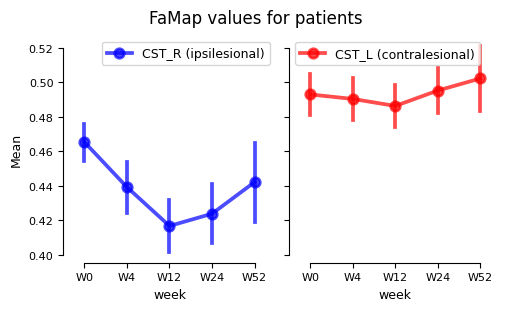

In [2]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, constrained_layout = True)
sns.pointplot(x = 'week', y = 'Mean', data = df[df.Object == regions[0]], alpha = .7, label = f'{regions[0]} (ipsilesional)', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Mean', data = df[df.Object == regions[1]], alpha = .7, label = f'{regions[1]} (contralesional)', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'{metric} values for patients')
plt.legend()
sns.despine(trim = True)
plt.show()

In [3]:
print(f'---t-test between affected and unaffected CST patients--- \n')

for week in df.week.unique():
    t_val, p_val = stats.ttest_rel(df[(df.week == week) & (df.Object == 'CST_R')]['Mean'], df[(df.week == week) & (df.Object == 'CST_L')]['Mean'])
    print(f'Week {week}: t-value = {t_val}, p-value = {p_val} \n')
    

---t-test between affected and unaffected CST patients--- 

Week W0: t-value = -2.998010658956938, p-value = 0.013389092635745201 

Week W4: t-value = -5.265448804718715, p-value = 7.693157112656951e-05 

Week W12: t-value = -5.29990082030336, p-value = 0.00011218969837145296 

Week W24: t-value = -5.745634567113927, p-value = 5.062911042553025e-05 

Week W52: t-value = -4.5189053264472285, p-value = 0.0011102200750641097 



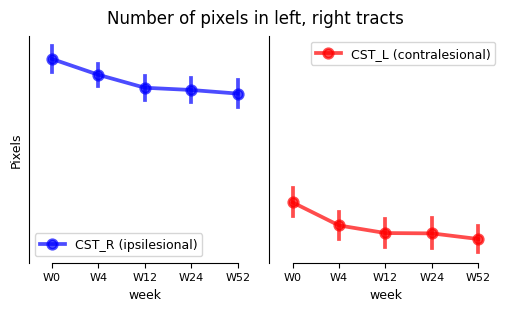

In [4]:
fig, axs = plt.subplots(1,2, figsize = (5,3), sharey = True, constrained_layout = True)
sns.pointplot(x = 'week', y = 'Pixels', data = df[df.Object == regions[0]], alpha = .7, label = f'{regions[0]} (ipsilesional)', color = 'blue', ax = axs[0], errorbar = 'se')
sns.pointplot(x = 'week', y = 'Pixels', data = df[df.Object == regions[1]], alpha = .7, label = f'{regions[1]} (contralesional)', color = 'red', ax = axs[1], errorbar = 'se')

plt.suptitle(f'Number of pixels in left, right tracts')
plt.legend()
axs[0].set_yticklabels([])
axs[0].set_yticks([])
sns.despine(trim = True)
plt.show()

In [5]:
p_df = pd.read_csv(os.path.join(gl.baseDir, 'participants.tsv'), sep = '\t')
p_subjs = p_df.subj_id.unique()
no_anat = df[~df.subj_id.isin(p_subjs)] # no lesion side in these patients

In [6]:
no_anat.subj_id.unique()

array([], dtype=object)